# CUADERNO JUPYTER UNIFICADO: Práctica 1 – Metaheurísticas (Curso 2025/2026)
## RANDOM SEARCH (RS)

## 1. Importación de librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import random
import time

: 

## 2. Carga de series temporales

In [ ]:
import os

def read_serie(path):

    with open(path, "r") as f:
        contenido = f.read().replace("[", "").replace("]", "").split()
        return [float(x) for x in contenido]

# Rutas correctas a tus archivos SIN extensión
files = [
    "../datos/TS1",
    "../datos/TS2",
    "../datos/TS3",
    "../datos/TS4"
]

series = [read_serie(f) for f in files]
k_values = [9, 10, 20, 50]
# TS1 → 9 segmentos
#  TS2 → 10 segmentos
#  TS3 → 20 segmentos
#  TS4 → 50 segmentos


print("✔ Series cargadas correctamente")

✔ Series cargadas correctamente


## 3. Regresión lineal por segmentos

In [3]:
from sklearn.linear_model import LinearRegression

def estimate_segment_coef(x, y):
    x = np.array(x).reshape(-1, 1)
    y = np.array(y)

    if len(x) < 2:
        return (0.0, 0.0)

    model = LinearRegression().fit(x, y)
    return (model.coef_[0], model.intercept_)


def estimate_all_coef(serie, points):
    coef = []
    start = 0

    pts = points.copy()
    pts.append(len(serie))

    for end in pts:
        x = list(range(start, end))
        y = serie[start:end]
        coef.append(estimate_segment_coef(x, y))
        start = end

    return coef


def estimate_all_points(coef, points, n):
    estimated = []
    start = 0

    pts = points.copy()
    pts.append(n)

    for idx, end in enumerate(pts):
        m, b = coef[idx]
        for i in range(start, end):
            estimated.append(m * i + b)
        start = end

    return estimated

###  **Regresión lineal por segmentos usando *scikit‑learn***  

En esta implementación utilizamos la librería `scikit‑learn` para ajustar una recta de regresión en cada segmento definido por los puntos de corte. Esto simplifica el código respecto a una primera versión en la que se calculó la pendiente y la ordenada al origen.

####  1. Ajuste de una recta en un segmento  
Para cada tramo de la serie temporal:

- Construimos el vector de posiciones `x = [start, start+1, ..., end-1]`.
- Extraemos los valores reales del segmento `y = serie[start:end]`.
- Ajustamos una regresión lineal usando:

```python
model = LinearRegression().fit(x, y)
```

- Obtenemos directamente:
  - **pendiente** → `model.coef_[0]`
  - **intercepto** → `model.intercept_`

Esto evita implementar fórmulas cerradas y mejora la estabilidad numérica.

####  2. Cálculo de coeficientes para todos los segmentos  
Recorremos los puntos de corte y ajustamos una recta para cada tramo.  
El resultado es una lista de pares `(pendiente, intercepto)`.

####  3. Generación de valores estimados  
Una vez obtenidos los coeficientes, reconstruimos la serie estimada evaluando cada recta en su intervalo correspondiente:

$$
\hat{y}(i) = m \cdot i + b
$$

donde `m` es la pendiente y `b` el intercepto del segmento.

## 4. Generación de puntos de corte aleatorios

In [4]:
# Este código genera puntos de corte aleatorios para dividir la serie temporal en segmentos.

def randomPoints(longitud_serie, n_cortes):

    b = []
    while n_cortes > 0:
        r = random.randint(1, longitud_serie - 1)
        if r not in b:
            b.append(r)
            n_cortes -= 1

    b.sort()
    return b

## 5. Cálculo del RMSE por segmento

In [5]:
def RMSE(y_real, y_pred):
    # Calcula el RMSE entre dos listas.
    mse = mean_squared_error(y_real, y_pred)
    return np.sqrt(mse)


def mean_rmse(serie, points):

    rmse_acc = 0.0
    start = 0

    coef = estimate_all_coef(serie, points.copy())
    estimated = estimate_all_points(coef, points.copy(), len(serie))

    pts = points.copy()
    pts.append(len(serie))

    for point in pts:
        rmse_acc += RMSE(serie[start:point], estimated[start:point])
        start = point

    return rmse_acc / len(pts)

### Evaluación detallada de una segmentación

Aunque, no se pide explícitamente, la siguiente función permite visualizar cómo de bien se ajustan las rectas obtenidas en cada segmento de la serie temporal.  
A partir de un conjunto de puntos de corte, calcula:

- Los coeficientes de cada recta ajustada  
- La serie estimada completa  
- El RMSE de cada segmento  
- El RMSE medio de toda la segmentación  

Esto resulta útil para inspeccionar la calidad de una segmentación concreta y entender mejor el comportamiento del algoritmo de Random Search.

In [6]:
def mostrar_evaluacion_segmentos(serie, points):

    coef = estimate_all_coef(serie, points.copy())
    estimated = estimate_all_points(coef, points.copy(), len(serie))

    pts = points.copy()
    pts.append(len(serie))

    print("\n=== Evaluación detallada de la segmentación ===")
    print(f"Puntos de corte: {points}\n")
    print("{:<10} {:<15} {:<10}".format("Segmento", "Rango", "RMSE"))

    start = 0
    for idx, point in enumerate(pts):
        rmse_seg = RMSE(serie[start:point], estimated[start:point])
        print("{:<10} {:<15} {:.4f}".format(
            idx+1,
            f"{start}:{point}",
            rmse_seg
        ))
        start = point

    print("\nRMSE medio:", mean_rmse(serie, points))

p = randomPoints(len(series[0]), 3)
mostrar_evaluacion_segmentos(series[0], p)


=== Evaluación detallada de la segmentación ===
Puntos de corte: [37, 108, 111]

Segmento   Rango           RMSE      
1          0:37            2.2160
2          37:108          3.4414
3          108:111         0.0168
4          111:200         3.3909

RMSE medio: 2.266293384698403


## 6. Implementación del algoritmo Random Search (RS)

### Búsqueda Aleatoria: función `randomSearch`

Esta función ejecuta el núcleo del algoritmo **Random Search (RS)**.  
Su objetivo es explorar distintas segmentaciones de la serie temporal de forma aleatoria y quedarse con la mejor encontrada.

En cada iteración:

1. Genera un conjunto aleatorio de puntos de corte.
2. Evalúa esa segmentación calculando su RMSE medio.
3. Compara el resultado con el mejor obtenido hasta el momento.
4. Si mejora, actualiza la solución óptima.
5. Registra la evolución del mejor RMSE a lo largo de las iteraciones.

Al finalizar, devuelve:
- La mejor segmentación encontrada (`best`)
- El tiempo total de ejecución
- El historial de mejoras del RMSE

Esta función constituye el motor de exploración del algoritmo RS.

In [7]:
def randomSearch(serie, k, n_iter, prev_best=None):

    if prev_best is None:
        best = {'rmse': float('inf'), 'points': None}
    else:
        best = prev_best

    startTime = time.time()
    rmses = []

    for i in range(n_iter):

        points = randomPoints(len(serie), k)
        rmse = mean_rmse(serie, points)

        if rmse < best['rmse']:
            best['rmse'] = rmse
            best['points'] = points

        rmses.append(best.copy())

    endTime = time.time()
    i_time = endTime - startTime

    return best, i_time, rmses

### 7. Definir ejecución

###  Ejecución del experimento completo con Random Search

La función `ejecutar_RS` implementa el experimento global de la práctica.  
Su objetivo es evaluar el rendimiento del algoritmo Random Search en distintos
escenarios y obtener resultados suficientes para analizar:

- **Exactitud** (mejor RMSE obtenido)
- **Variabilidad** (20 repeticiones independientes)
- **Tiempo de cómputo**
- **Evolución del RMSE** según el número de iteraciones

Para cada repetición y para cada serie temporal (TS1–TS4), el algoritmo ejecuta
Random Search con un número creciente de iteraciones (10, 20, 30, …, 190).  
En cada caso se almacena:

- El mejor RMSE encontrado
- Los puntos de corte óptimos
- El tiempo de ejecución

Estos datos se utilizarán posteriormente para generar las gráficas de evolución
del RMSE y para justificar formalmente qué método es más adecuado en el informe.

In [10]:
def ejecutar_RS(series, k_values, start=10, end=200, step=10, repeticiones=20):

    resultados = []

    print("\n=== Ejecutando experimento Random Search ===")

    for rep in range(repeticiones):
        print(f"Repetición {rep+1}/{repeticiones} completada")
        rep_result = []

        for idx, serie in enumerate(series):
            k = k_values[idx]
            best = None
            serie_result = []

            for n in range(start, end, step):
                best, tiempo, historial = randomSearch(serie, k, step, best)

                serie_result.append({
                    "iter": n,
                    "rmse": best["rmse"],
                    "points": best["points"],
                    "tiempo": tiempo
                })

            rep_result.append(serie_result)

        resultados.append(rep_result)

    print("=== Experimento finalizado ===\n")
    return resultados

## 8. Ejecución completa del experimento

Para analizar adecuadamente el comportamiento de Random Search, el experimento se ejecutó **20 veces de forma independiente**. Este número de repeticiones es habitual en el ámbito de las metaheurísticas, ya que permite:

- obtener una **estimación estable de la media del RMSE**,  
- calcular la **variabilidad** mediante la desviación típica,  
- y hacerlo sin incrementar de forma excesiva el **tiempo de cómputo**.

Estas repeticiones permiten evaluar con rigor la **exactitud**, **robustez** y **estabilidad** del método, tal como exige el enunciado de la práctica.

In [9]:
resultados_RS = ejecutar_RS(series, k_values, start=10, end=200, step=10, repeticiones=20)


=== Ejecutando experimento Random Search ===
Repetición 1/20 completada
Repetición 2/20 completada
Repetición 3/20 completada
Repetición 4/20 completada
Repetición 5/20 completada
Repetición 6/20 completada
Repetición 7/20 completada
Repetición 8/20 completada
Repetición 9/20 completada
Repetición 10/20 completada
Repetición 11/20 completada
Repetición 12/20 completada
Repetición 13/20 completada
Repetición 14/20 completada
Repetición 15/20 completada
Repetición 16/20 completada
Repetición 17/20 completada
Repetición 18/20 completada
Repetición 19/20 completada
Repetición 20/20 completada
=== Experimento finalizado ===



## 9. Visualización de resultados

### 9.1. Evolución del **RMSE**

Este apartado muestra la evolución del error cuadrático medio (RMSE) a lo largo de las iteraciones del algoritmo **Random Search** para cada serie temporal.  
Las gráficas permiten analizar la estabilidad y la capacidad de mejora del método conforme aumenta el número de iteraciones.

**Cada gráfica incluye:**

- **Media del RMSE** obtenida en las 20 repeticiones del experimento.  
- **Banda de ±1 desviación típica**, que refleja la variabilidad del algoritmo.  
- **Marcadores de inicio y fin**, que destacan visualmente el comportamiento del método en los extremos del rango de iteraciones.

In [11]:
def plot_RS(series, resultados):

    print(">>> Generando gráficas de Búsqueda Aleatoria...")

    num_series = len(series)

    for idx in range(num_series):
        print(f"- Procesando Serie TS{idx+1}...")

        # Extraer RMSE por iteración para todas las repeticiones
        rmse_iters = np.array([
            [it["rmse"] for it in rep[idx]]
            for rep in resultados
        ])

        # Media y desviación típica
        mean_rmse = rmse_iters.mean(axis=0)
        std_rmse = rmse_iters.std(axis=0)

        # Iteraciones reales (10, 20, ..., 190)
        iters = [it["iter"] for it in resultados[0][idx]]

        # Crear figura
        plt.figure(figsize=(12, 5))

        # Banda de desviación típica (más suave)
        plt.fill_between(
            iters,
            mean_rmse - std_rmse,
            mean_rmse + std_rmse,
            color="#4A90E2",
            alpha=0.20,
            label="±1 desviación"
        )

        # Línea principal
        plt.plot(
            iters,
            mean_rmse,
            color="#1F4E79",
            linewidth=2.2,
            marker="o",
            markersize=5,
            label="Media RMSE"
        )

        # Marcadores de inicio y fin
        plt.scatter(iters[0], mean_rmse[0], color="green", s=80, label="Inicio")
        plt.scatter(iters[-1], mean_rmse[-1], color="red", s=80, label="Fin")

        # Estética del gráfico
        plt.title(f"Evolución del RMSE - Random Search (TS{idx+1})", fontsize=14, fontweight="bold")
        plt.xlabel("Iteraciones", fontsize=12)
        plt.ylabel("RMSE", fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.legend()
        plt.tight_layout()
        plt.show()

    print(">>> Gráficas generadas correctamente.")


>>> Generando gráficas de Búsqueda Aleatoria...
- Procesando Serie TS1...


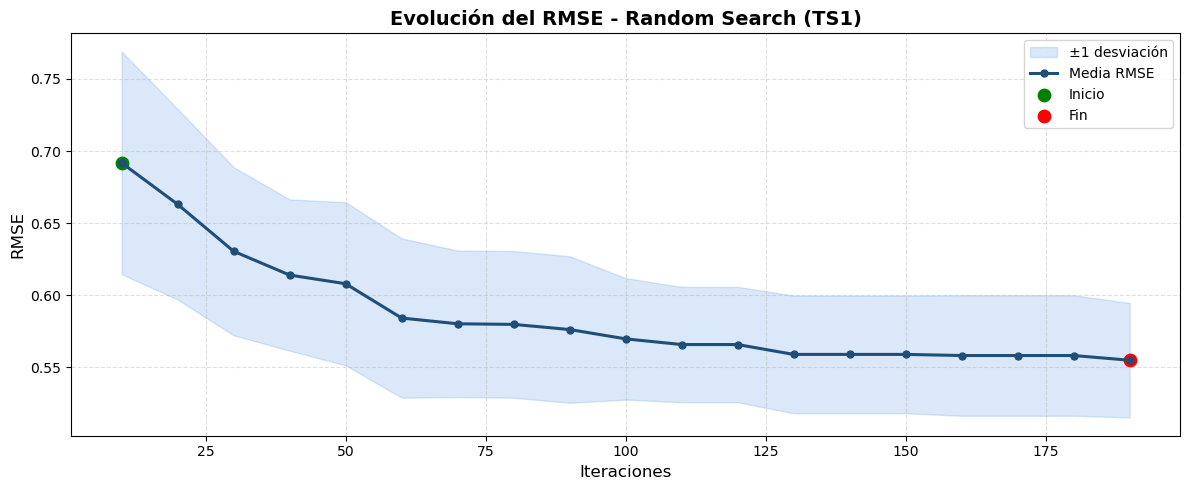

- Procesando Serie TS2...


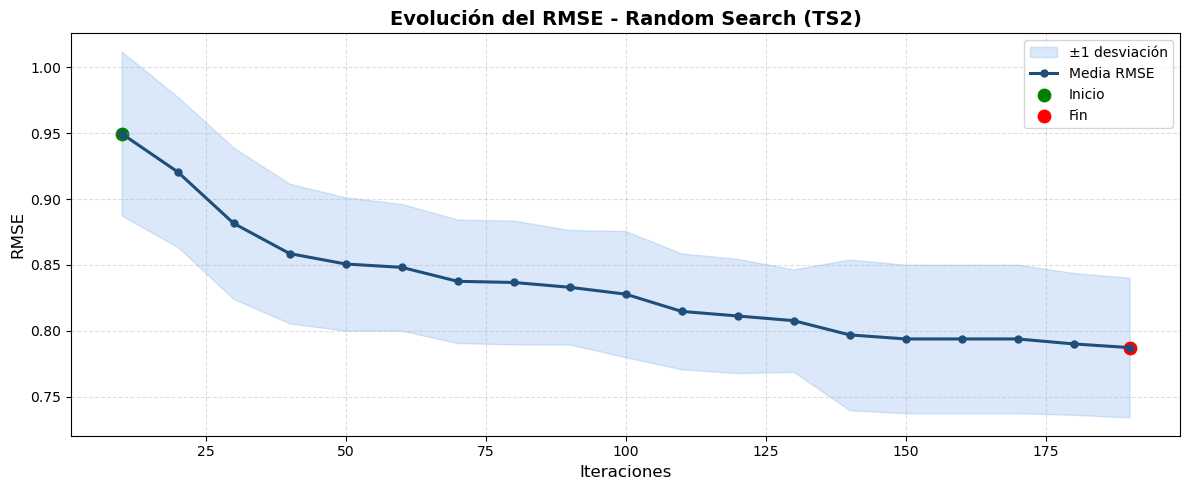

- Procesando Serie TS3...


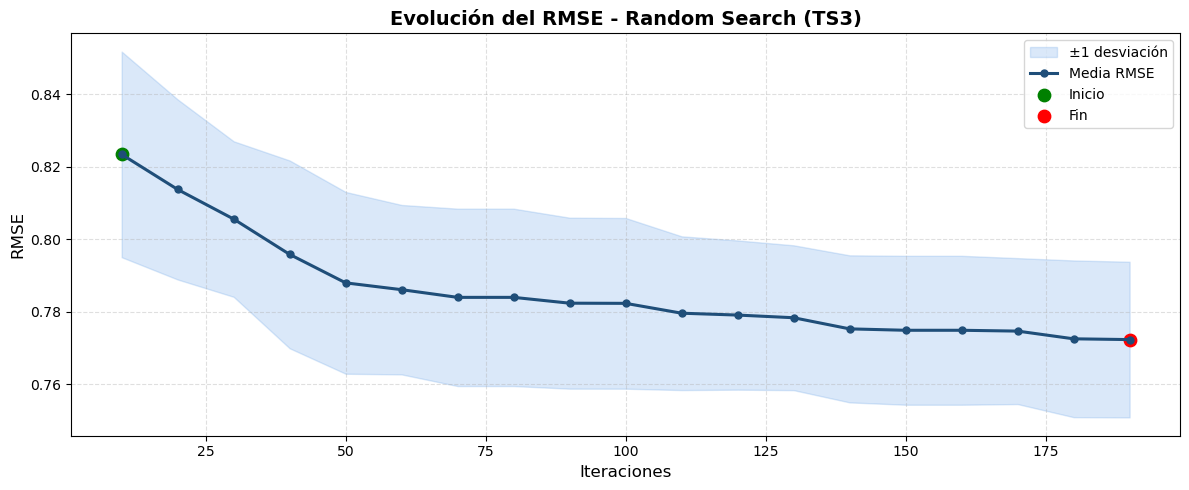

- Procesando Serie TS4...


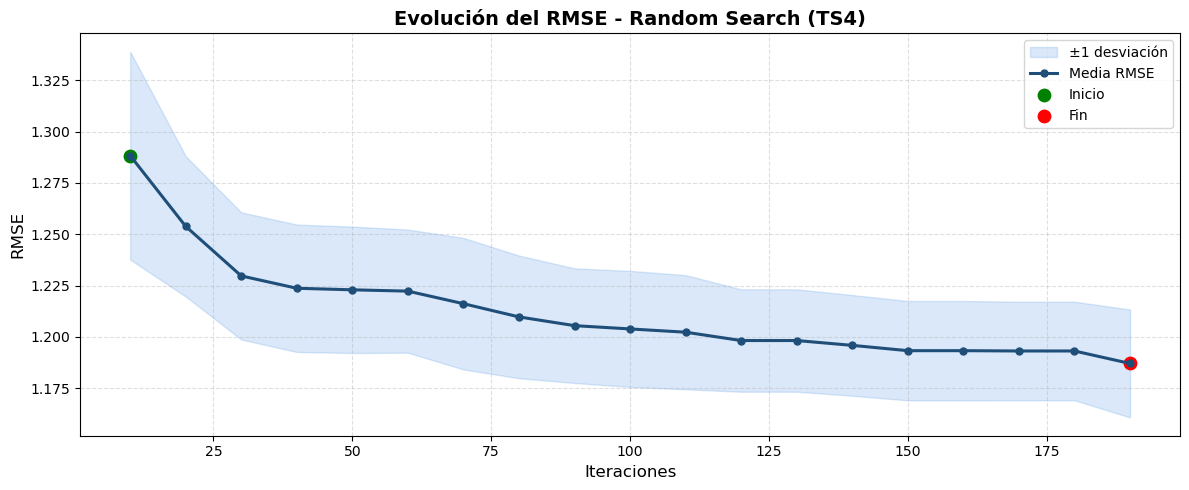

>>> Gráficas generadas correctamente.


In [12]:
plot_RS(series, resultados_RS)

### 9.2 Representación gráfica de la segmentación final

Además de analizar la evolución del RMSE a lo largo de las iteraciones, es importante visualizar la **solución final** obtenida por el algoritmo de Búsqueda Aleatoria. 

Para cada serie temporal (TS1–TS4), se representa:

- La **serie real** (en azul).
- La **serie estimada** a partir de los segmentos óptimos (en rojo).
- Las **líneas verticales** que indican los puntos de corte seleccionados por el algoritmo.

Estas gráficas permiten comprobar visualmente si las rectas ajustadas siguen adecuadamente la forma de la serie y si la segmentación obtenida es coherente con la estructura de los datos. Además, facilitan la comparación posterior con las soluciones obtenidas mediante Hill Climbing y Simulated Annealing.

In [13]:
def plot_final_solutions(series, resultados, k_values):
    
   # Dibuja la solución final encontrada por Random Search para cada serie temporal.
   # Muestra:
    #- Serie real (azul)
    #- Serie estimada (rojo)
    #- Líneas verticales en los puntos de corte óptimos
   

    for idx, serie in enumerate(series):
        # Extraer el mejor conjunto de puntos de corte de la última repetición
        best_points = resultados[-1][idx][-1]["points"]

        # Calcular la serie estimada
        coef = estimate_all_coef(serie, best_points.copy())
        estimada = estimate_all_points(coef, best_points.copy(), len(serie))

        # Crear figura
        plt.figure(figsize=(12, 5))
        plt.plot(serie, label="Serie real", color="blue")
        plt.plot(estimada, label="Serie estimada", color="red")

        # Dibujar líneas verticales en los puntos de corte
        for p in best_points:
            plt.axvline(x=p, color="black", linestyle="--", alpha=0.7)

        plt.title(f"Solución final RS - TS{idx+1} (k={k_values[idx]})")
        plt.xlabel("Tiempo")
        plt.ylabel("Valor")
        plt.legend()
        plt.grid(True)

        # Guardar imagen
        plt.savefig(f"TS{idx+1}_sol.png", dpi=150)
        plt.show()

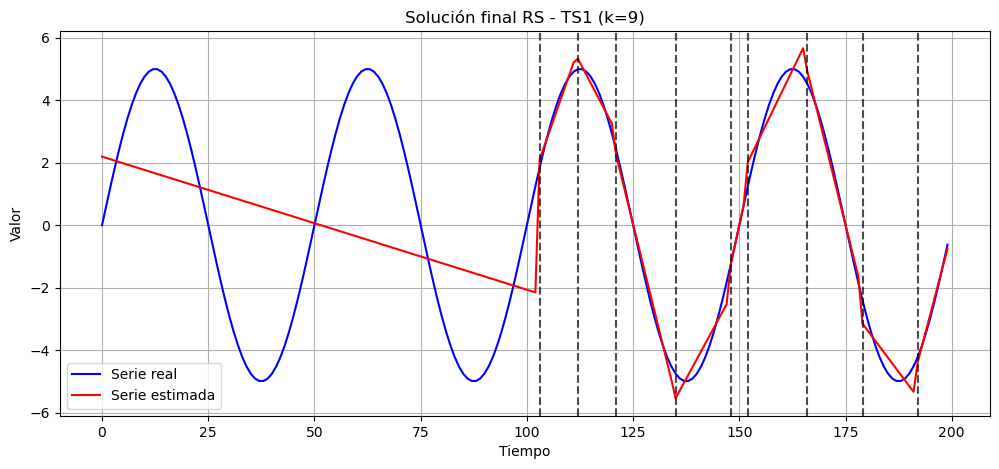

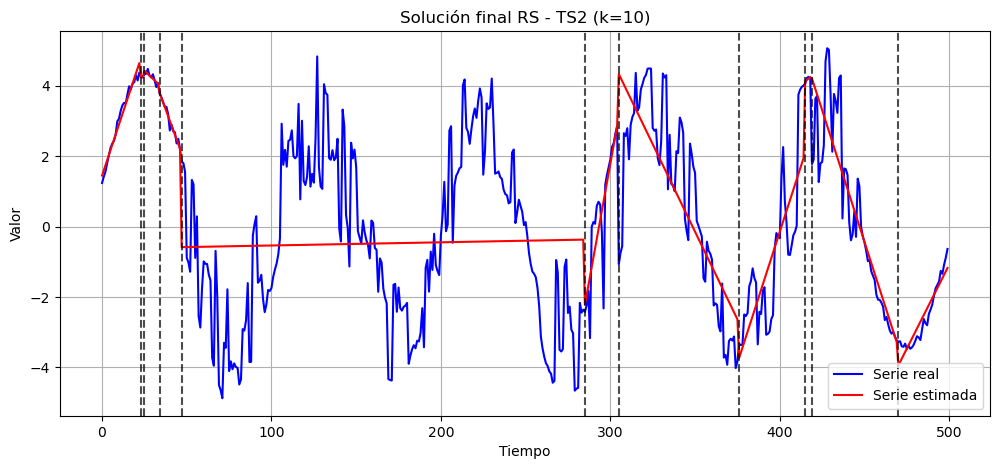

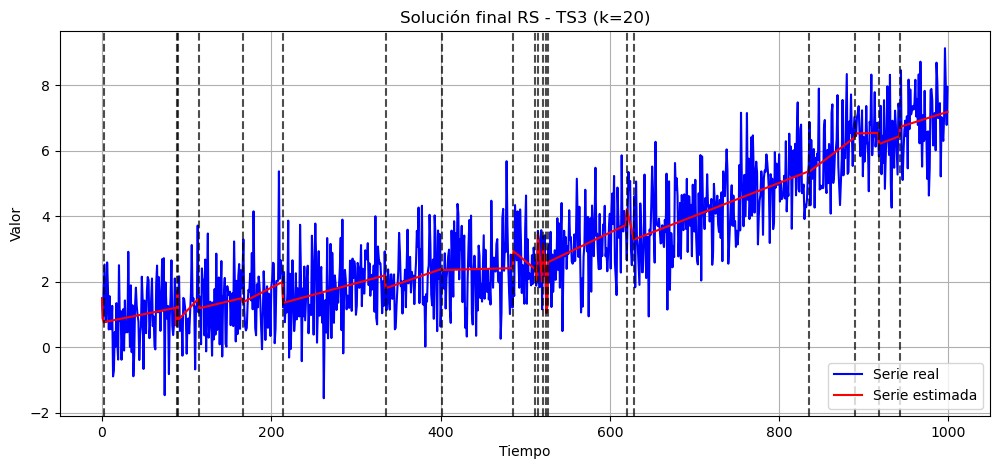

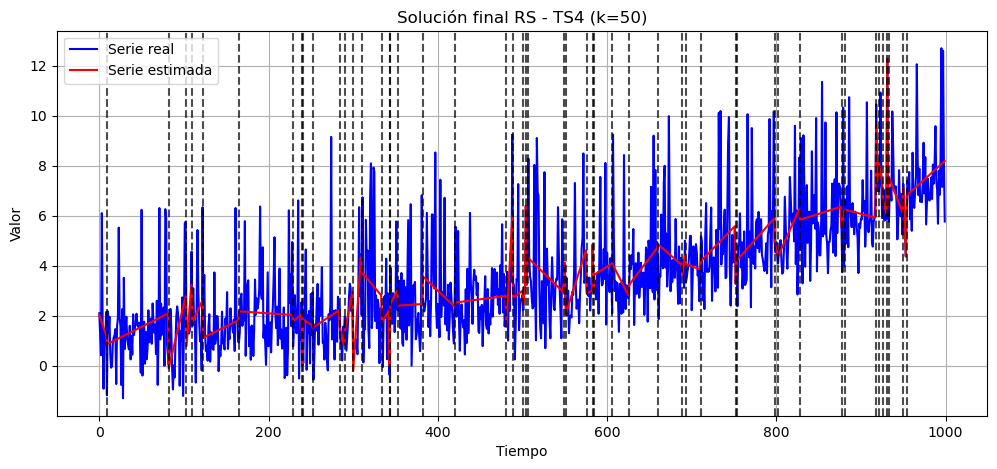

In [16]:
plot_final_solutions(series, resultados_RS, k_values)

## 10.  Obtención de métricas para comparar los tres algoritmos.

Para cada serie (TS1, TS2, TS3, TS4) y para cada algoritmo (RS, HC, SA), necesitamos:

**Exactitud**  
→ El RMSE medio final (cuanto más bajo, mejor)

**Variabilidad**  
→ La desviación típica del RMSE entre repeticiones  
(mide estabilidad)

**Tiempo de cómputo**  
→ El tiempo medio por repetición  
(mide eficiencia)

La función `ejecutar_RS` ya guarda:

- `"rmse"`  
- `"tiempo"`  
- `"points"`  
- `"iter"`

Y lo hace **para cada repetición**.

Así que solo necesitamos **procesar esos datos** para obtener:

- media del RMSE final  
- desviación típica del RMSE final  
- media del tiempo total  


### 10.1. EXTRAER EXACTITUD (RMSE final)

In [14]:
def exactitud_RS(resultados):
    medias = []
    for serie in range(len(resultados[0])):  # 4 series
        rmse_final = [rep[serie][-1]["rmse"] for rep in resultados]
        medias.append(np.mean(rmse_final))
    return medias

### 10.2. EXTRAER VARIABILIDAD (desviación típica)

In [15]:
def variabilidad_RS(resultados):
    desv = []
    for serie in range(len(resultados[0])):
        rmse_final = [rep[serie][-1]["rmse"] for rep in resultados]
        desv.append(np.std(rmse_final))
    return desv

### 10.3. EXTRAER TIEMPO DE CÓMPUTO

In [16]:
def tiempo_RS(resultados):
    tiempos = []
    for serie in range(len(resultados[0])):
        tiempo_total = [sum([it["tiempo"] for it in rep[serie]]) for rep in resultados]
        tiempos.append(np.mean(tiempo_total))
    return tiempos

### 10.4. CALCULAR MÉTRICAS

In [17]:
# Calcular métricas
rmse_medios = exactitud_RS(resultados_RS)
rmse_desv = variabilidad_RS(resultados_RS)
tiempos_medios = tiempo_RS(resultados_RS)

# Crear tabla
series = ["TS1 (k=9)", "TS2 (k=10)", "TS3 (k=20)", "TS4 (k=50)"]

tabla = pd.DataFrame({
    "Serie": series,
    "RMSE medio": rmse_medios,
    "Desviación típica": rmse_desv,
    "Tiempo medio (s)": tiempos_medios
})

from tabulate import tabulate
tabla_formateada = tabla.copy()
tabla_formateada["RMSE medio"] = tabla_formateada["RMSE medio"].map("{:.6f}".format)
tabla_formateada["Desviación típica"] = tabla_formateada["Desviación típica"].map("{:.6f}".format)
tabla_formateada["Tiempo medio (s)"] = tabla_formateada["Tiempo medio (s)"].map("{:.6f}".format)

print(tabulate(tabla_formateada, headers="keys", tablefmt="fancy_grid", showindex=False))

╒════════════╤══════════════╤═════════════════════╤════════════════════╕
│ Serie      │   RMSE medio │   Desviación típica │   Tiempo medio (s) │
╞════════════╪══════════════╪═════════════════════╪════════════════════╡
│ TS1 (k=9)  │     0.555001 │            0.039645 │            2.31704 │
├────────────┼──────────────┼─────────────────────┼────────────────────┤
│ TS2 (k=10) │     0.787193 │            0.053067 │            2.4822  │
├────────────┼──────────────┼─────────────────────┼────────────────────┤
│ TS3 (k=20) │     0.772294 │            0.021473 │            4.71312 │
├────────────┼──────────────┼─────────────────────┼────────────────────┤
│ TS4 (k=50) │     1.18702  │            0.026293 │           11.0229  │
╘════════════╧══════════════╧═════════════════════╧════════════════════╛
